## Setup

In [2]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.status()

  Activating project at `~/Documents/Carnegie-Mellon/Chatterjee Group/Programming/WignerMolecule.jl/high-temp`


Status `~/Documents/Carnegie-Mellon/Chatterjee Group/Programming/WignerMolecule.jl/high-temp/Project.toml`
  [13f3f980] CairoMakie v0.15.10
  [033835bb] JLD2 v0.6.4
  [eff96d63] Measurements v2.14.1
  [295af30f] Revise v3.14.3
  [a601b020] WignerMolecule v1.0.0-DEV `..`
  [37e2e46d] LinearAlgebra v1.12.0


In [3]:
include("Expectation.jl")
using .Expectations
using CairoMakie
using JLD2
using LinearAlgebra
using Measurements

In [4]:
function Measurements.measurement(e::Expectation)
    return e.val ± e.err
end

function cumulant(moms::Vector{T}, ord) where {T <: Real}
    M = Matrix{T}(undef, ord, ord)
    for I in eachindex(IndexCartesian(), M)
        i, j = Tuple(I)
        mom = i-j < 0 ? 1 : moms[i-j+1]
        M[I] = mom * binomial(i-1, max(j-2, 0))
    end
    return (-1)^(ord+1) * det(M)
end

"""
    getexpansion(name, ord)

Read high-T expansion coefficients for energy from JLD2 file to order ord,
returns closure accepting T
"""
function getexpansion(name, ord)
    all_data = load("expectations.jld2")
    energies = [measurement(all_data["$name/HH$i"]) for i in 0:(ord-1)]
    cumulants = [cumulant(energies, i) for i in 1:ord]
    return T -> getfield.(sum([(-1/T)^i / factorial(i) for i in 0:(ord-1)] .* cumulants), :val)
end

getexpansion

In [5]:
all_data = load("expectations.jld2")
energies = [measurement(all_data["stripe/HH$i"]) for i in 0:5]
cumulant(energies, 4)

116.0 ± 54.0

## Stripe

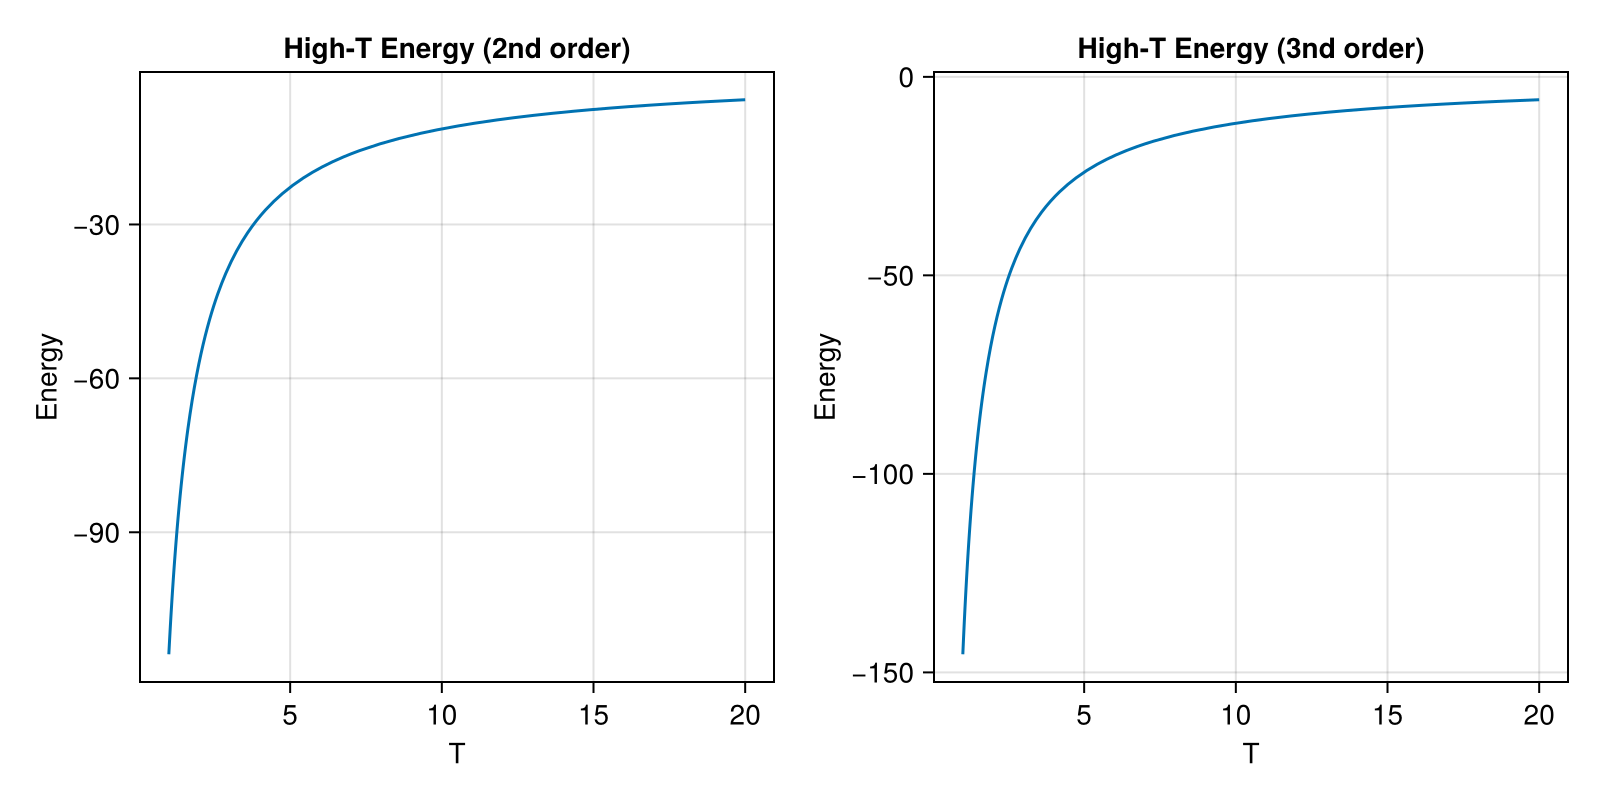

In [6]:
fig = Figure(size=(800,400))
fig[1,1] = ax1 = Axis(fig, title="High-T Energy (2nd order)", xlabel="T", ylabel="Energy")
lines!(ax1, 1..20, getexpansion("stripe", 2))
fig[1,2] = ax2 = Axis(fig, title="High-T Energy (3nd order)", xlabel="T", ylabel="Energy")
lines!(ax2, 1..20, getexpansion("stripe", 3))
fig